# ***COAST DOWN***

Resumo da etapa de reducao de resistencia e preparacao dos dados de VDE para modelagem.


## 1 - Setup Inicial

Carrega dependencias, abre o banco SQLite e combina tabelas relevantes para analise.


In [2]:
import sqlite3
import pandas as pd
from pathlib import Path

In [3]:
# Caminho do arquivo .db
db_path = "EcoDrive-Analyst/data/db/eco_drive.db"

# Abrindo conexão com o banco
conn = sqlite3.connect(db_path)

# Listando as tabelas disponíveis
query_tables = "SELECT name FROM sqlite_master WHERE type='table';"
tabelas = pd.read_sql_query(query_tables, conn)

# Habilitando chaves estrangeiras
conn.execute("PRAGMA foreign_keys=ON;")

# Realizando JOIN entre as tabelas vde_db e fuelcons_db
df_all=pd.read_sql("""
SELECT *
FROM vde_db v
JOIN fuelcons_db f ON f.vde_id = v.id
ORDER BY v.id ASC
""", conn)

df_all.head(3)

,id,created_at,updated_at,legislation,category,make,model,year,notes,engine_type,...,label_version_year,label_vehicle_category,label_cycle_set,label_class,label_offcycle_method,label_offcycle_energy_factor,label_offcycle_fuel_factor,label_fuel_l_per_100km,label_gco2_per_km,label_range_km
0,1,2025-10-07 05:15:33,None,EPA,MINICOMPACT CARS,ASTON MARTIN,DB12 V8,2025,From EPA test car dataset,None,...,2025.0,Minicompact Cars,2-cycle,None,None,None,None,10.450970,244.718780,None
1,2,2025-10-07 05:15:33,None,EPA,STANDARD SUVS,ASTON MARTIN,DBX 707,2025,From EPA test car dataset,None,...,2025.0,Standard SUVs,2-cycle,None,None,None,None,10.884284,259.036291,None
2,3,2025-10-07 05:15:33,None,EPA,TWO SEATERS,ASTON MARTIN,VANQUISH,2025,From EPA test car dataset,None,...,2025.0,Two Seaters,2-cycle,None,None,None,None,11.550805,273.798858,None


In [4]:
df_all.shape

(5004, 139)

-- --

## 2 - Limpeza dos Dados

Aplica filtro inicial e verifica nulidade para garantir integridade antes da modelagem.


In [5]:
# Filtrando linhas específicas do DataFrame
df_filtred = df_all.iloc[1:4999, :]
df_filtred.shape

(4998, 139)

In [6]:
# Selecionando features
X = df_filtred[
    [
        "category",
        "make",
        "year",
        "engine_size_l",
        "transmission_type",
        "drive_type",
        "electrification",
        "gear_count",
        "final_drive_ratio",
    ]
]

# Selecionando targets
y = df_filtred[
    ["coast_A_N",
    "coast_B_N_per_kph",
    "coast_C_N_per_kph2",
    "vde_net_mj_per_km"]
]

X.shape, y.shape

((4998, 9), (4998, 4))

In [7]:
# Analisando estatísticas descritivas das features
X.describe()

,year,engine_size_l,gear_count,final_drive_ratio
count,4998.000000,4998.000000,4998.000000,4998.000000
mean,2022.592237,4.072732,6.130852,3.805045
std,1.695854,12.248622,3.241047,1.783316
min,2020.000000,0.001000,1.000000,0.000000
25%,2021.000000,1.984000,1.000000,3.080000
50%,2023.000000,2.487000,8.000000,3.420000
75%,2024.000000,3.500000,8.000000,3.940000
max,2025.000000,99.999000,10.000000,9.990000


In [8]:
# Analisando estatísticas descritivas dos targets
y.describe()

,coast_A_N,coast_B_N_per_kph,coast_C_N_per_kph2,vde_net_mj_per_km
count,4998.000000,4998.000000,4998.000000,4998.000000
mean,185.846055,0.583356,0.040521,0.574741
std,55.643986,0.818328,0.011711,0.108253
min,71.697071,-2.148455,0.016144,0.316618
25%,144.863751,0.100057,0.032349,0.500052
50%,179.515545,0.585415,0.038748,0.561186
75%,216.672875,1.099242,0.046425,0.631161
max,411.705152,4.325655,0.113353,1.161238


-- --

## 3 - Analise Exploratoria

Explora distribuicoes e correlacoes das variaveis para entender padroes e sinais fortes.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

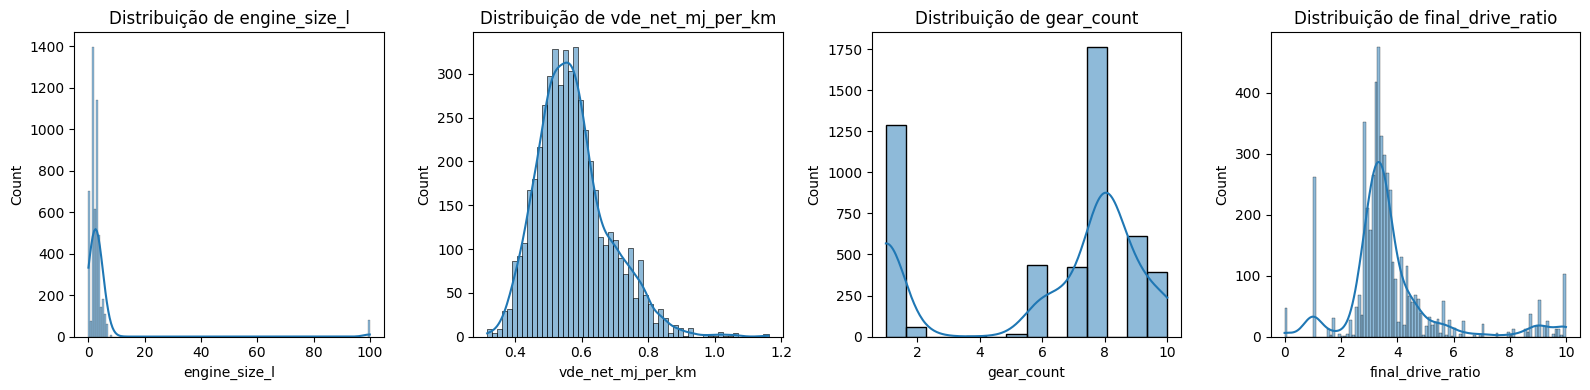

In [10]:
# Selecionar apenas variáveis numéricas
numeric_vars = X.select_dtypes(include=['number']).columns.tolist()

# Gráfico para a análise multivariada entre as variáveis numéricas e a variável Case
plt.figure(figsize=(16, 4))

# Variáveis a serem plotadas
plot_vars = []
for v in ["engine_size_l", "vde_net_mj_per_km", "gear_count", "final_drive_ratio"]:
    if v in df_filtred.columns:
        plot_vars.append(v)

# Criando subplots para cada variável
for i, var in enumerate(plot_vars, 1):
    plt.subplot(1, len(plot_vars), i)
    sns.histplot(data=df_filtred, x=var, kde=True)
    plt.title(f"Distribuição de {var}")
    plt.tight_layout()

plt.show()

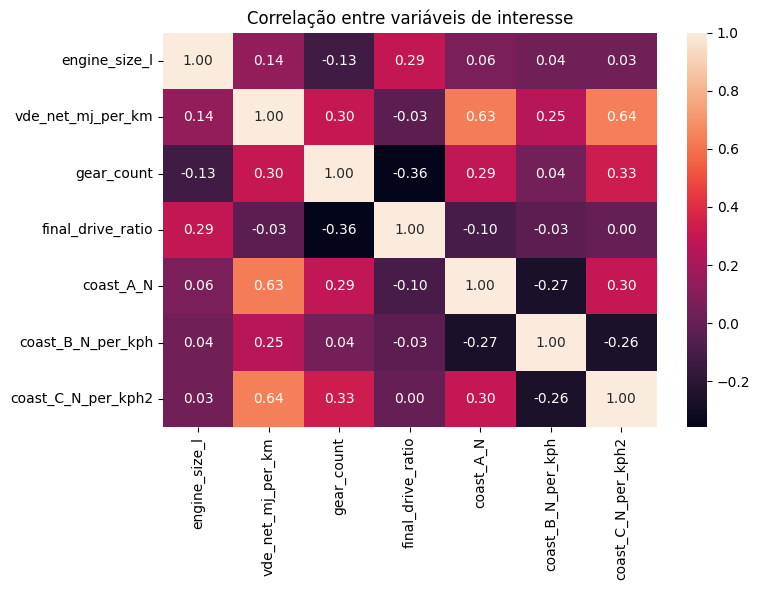

In [11]:
corr_cols = []

# Selecionando colunas para a matriz de correlação
for v in [
    "engine_size_l",
    "vde_net_mj_per_km",
    "gear_count",
    "final_drive_ratio",
    "coast_A_N",
    "coast_B_N_per_kph",
    "coast_C_N_per_kph2",
]:
    if v in df_filtred.columns:
        corr_cols.append(v)

# Calculando a matriz de correlação
corr_matrix = df_filtred[corr_cols].corr()

# Plotando a matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlação entre variáveis de interesse")
plt.tight_layout()
plt.show()

-- --

## 4 - Pre-processamento

Define colunas numericas e categoricas, com escalonamento e one-hot, preparando o pipeline.


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [13]:
X.isnull().sum()

category             0
make                 0
year                 0
engine_size_l        0
transmission_type    0
drive_type           0
electrification      0
gear_count           0
final_drive_ratio    0
dtype: int64

In [14]:
X.head()

,category,make,year,engine_size_l,transmission_type,drive_type,electrification,gear_count,final_drive_ratio
1,STANDARD SUVS,ASTON MARTIN,2025,4.0,AT,4WD,ICE,9,3.27
2,TWO SEATERS,ASTON MARTIN,2025,5.2,AT,RWD,ICE,8,2.93
3,TWO SEATERS,ASTON MARTIN,2025,4.0,AT,RWD,ICE,8,3.08
4,SUBCOMPACT CARS,BMW,2025,2.0,AMT,RWD,ICE,8,2.81
5,SUBCOMPACT CARS,BMW,2025,2.0,AMT,AWD,ICE,8,2.81


In [15]:
# Definindo pré-processamento para features contínuas e categóricas
continuous_features = [
    "engine_size_l",
    "gear_count",
    "final_drive_ratio",
    "year"
]

categorical_features = [
    "category",
    "make",
    "transmission_type",
    "drive_type",
    "electrification",
]

# Configurando o pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features), # scaling para variáveis contínuas
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # codificação para variáveis categóricas
    ],
     remainder='passthrough' #  manter outras colunas sem alterações
)

-- --

## 5 - Treinamento dos Modelos

Divide em treino/teste e avalia diferentes regressoes multialvo com metricas MAE e R2.


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Função para gerar relatório de regressão
def regression_report(y_true, y_pred, target_names=None):
    if target_names is None:
        target_names = [f"target_{i}" for i in range(y_true.shape[1])]

    for i, name in enumerate(target_names):
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2   = r2_score(y_true[:, i], y_pred[:, i])

        print(f"=== {name} ===")
        print(f"MAE : {mae:.4f}")
        print(f"R²  : {r2:.4f}")
        print()

### 5.1 - Linear Regression

In [19]:
model_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model_1.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
y_pred_1 = model_1.predict(X_test)

regression_report(y_test.values, y_pred_1, target_names=y_test.columns)

=== coast_A_N ===
MAE : 27.6768
R²  : 0.6017

=== coast_B_N_per_kph ===
MAE : 0.4494
R²  : 0.4649

=== coast_C_N_per_kph2 ===
MAE : 0.0050
R²  : 0.6406

=== vde_net_mj_per_km ===
MAE : 0.0460
R²  : 0.6752



-- --

### 5.2 - Random Forest

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [22]:
model_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=180, random_state=42))
])

model_2.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
y_pred_2 = model_2.predict(X_test)
regression_report(y_test.values, y_pred_2, target_names=y_test.columns)

=== coast_A_N ===
MAE : 14.6828
R²  : 0.8492

=== coast_B_N_per_kph ===
MAE : 0.2103
R²  : 0.8330

=== coast_C_N_per_kph2 ===
MAE : 0.0025
R²  : 0.8827

=== vde_net_mj_per_km ===
MAE : 0.0235
R²  : 0.8993



-- --

### 5.3 - Neural Network

In [24]:
from sklearn.neural_network import MLPRegressor

In [25]:
model_3 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            MLPRegressor(
                hidden_layer_sizes=(100, 50),
                activation="logistic",
                solver="adam",
                learning_rate="adaptive",
                random_state=42,
                early_stopping=True,
                alpha=0.001,
                max_iter=1000
            ),
        ),
    ]
)

model_3.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
y_pred_3 = model_3.predict(X_test)
regression_report(y_test.values, y_pred_3, target_names=y_test.columns)

=== coast_A_N ===
MAE : 43.0138
R²  : -0.0084

=== coast_B_N_per_kph ===
MAE : 0.6094
R²  : -0.0001

=== coast_C_N_per_kph2 ===
MAE : 0.0086
R²  : -0.0014

=== vde_net_mj_per_km ===
MAE : 0.0842
R²  : -0.0030



-- --

### 5.4 - SVM

In [27]:
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

In [28]:
model_4 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            MultiOutputRegressor(
                SVR(kernel="rbf", C=10, gamma='scale', epsilon=0.1)
            ),
        ),
    ]
)

model_4.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
y_pred_4 = model_4.predict(X_test)
regression_report(y_test.values, y_pred_4, target_names=y_test.columns)

=== coast_A_N ===
MAE : 23.9795
R²  : 0.6342

=== coast_B_N_per_kph ===
MAE : 0.2490
R²  : 0.7795

=== coast_C_N_per_kph2 ===
MAE : 0.0254
R²  : -4.5142

=== vde_net_mj_per_km ===
MAE : 0.0480
R²  : 0.7186



-- --

# ***FUEL CONSUMPTION***



## ***Pre Processing***
### Modelagem de consumo de combustivel/energia a partir das variaveis de VDE e coastdown.

In [30]:
# Selecionando features
X_fc = df_filtred[
    [
        "category",
        "make",
        "year",
        "engine_size_l",
        "transmission_type",
        "drive_type",
        "electrification",
        "gear_count",
        "final_drive_ratio",
        "coast_A_N",
        "coast_B_N_per_kph",
        "coast_C_N_per_kph2",
        "vde_net_mj_per_km",
        "vde_urb_mj_per_km",
        "vde_hw_mj_per_km",
    ]
]

# Selecionando targets
y_fc = df_filtred[
    [
        "fuel_ftp75_l_per_100km",
        "fuel_hwfet_l_per_100km",
        "fuel_l_per_100km",
        "energy_ftp75_Wh_per_km",
        "energy_hwfet_Wh_per_km",
        "energy_Wh_per_km",
    ]
]

X_fc.shape, y_fc.shape

((4998, 15), (4998, 6))

In [31]:
X_fc_nbev = X_fc[X_fc["electrification"] != "BEV"]

y_fc_nbev = y_fc[X_fc["electrification"] != "BEV"].drop(columns=
    [
        "energy_ftp75_Wh_per_km",
        "energy_hwfet_Wh_per_km",
        "energy_Wh_per_km",
    ]
)

In [32]:
y_fc_nbev

,fuel_ftp75_l_per_100km,fuel_hwfet_l_per_100km,fuel_l_per_100km
1,12.714302,8.647595,10.884284
2,14.342353,8.138913,11.550805
3,12.314900,7.538929,10.165713
4,6.857568,4.621112,5.851163
5,7.396685,4.879971,6.264164
...,...,...,...
4994,9.260417,6.046647,7.814220
4995,7.106181,5.880365,6.554563
4996,8.647595,5.508538,7.235019
4997,10.619169,6.365753,8.705132


In [33]:
y_fc_nbev.isna().sum()

fuel_ftp75_l_per_100km    10
fuel_hwfet_l_per_100km    11
fuel_l_per_100km          15
dtype: int64

In [34]:
mask = ~y_fc_nbev.isna().any(axis=1)

X_fc_nbev = X_fc_nbev[mask]
y_fc_nbev = y_fc_nbev[mask]

In [35]:
X_fc_nbev.shape, y_fc_nbev.shape

((4202, 15), (4202, 3))

-- --

In [36]:
X_fc_bev = X_fc[X_fc["electrification"] == "BEV"]

y_fc_bev = y_fc[X_fc["electrification"] == "BEV"].drop(columns=
    [
        "fuel_ftp75_l_per_100km",
        "fuel_hwfet_l_per_100km",
        "fuel_l_per_100km"
    ]
)

In [37]:
y_fc_bev.isna().sum()

energy_ftp75_Wh_per_km    145
energy_hwfet_Wh_per_km    137
energy_Wh_per_km          136
dtype: int64

In [38]:
mask = ~y_fc_bev.isna().any(axis=1)

X_fc_bev = X_fc_bev[mask]
y_fc_bev = y_fc_bev[mask]

In [39]:
X_fc_bev.shape, y_fc_bev.shape

((635, 15), (635, 3))

-- --

In [40]:
# Definindo pré-processamento para features contínuas e categóricas
continuous_features = [
    "engine_size_l",
    "gear_count",
    "final_drive_ratio",
    "year",
    "coast_A_N",
    "coast_B_N_per_kph",
    "coast_C_N_per_kph2",
    "vde_net_mj_per_km",
    "vde_urb_mj_per_km",
    "vde_hw_mj_per_km",
]

categorical_features = [
    "category",
    "make",
    "transmission_type",
    "drive_type",
    "electrification",
]

# Configurando o pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            continuous_features,
        ),  # scaling para variáveis contínuas
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),  # codificação para variáveis categóricas
    ],
    remainder="passthrough",  #  manter outras colunas sem alterações
)

-- --

## BEV

Conjunto de modelos focado em veiculos eletricos puros, prevendo consumo energetico.


In [41]:
X_fc_bev_train, X_fc_bev_test, y_fc_bev_train, y_fc_bev_test = train_test_split(
    X_fc_bev, y_fc_bev, test_size=0.2, random_state=42
)

### 5.1 - Random Forest

In [42]:
model_bev_1 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(n_estimators=200, random_state=42),
        ),
    ]
)
model_bev_1.fit(X_fc_bev_train, y_fc_bev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
y_bev_pred_1 = model_bev_1.predict(X_fc_bev_test)
regression_report(y_fc_bev_test.values, y_bev_pred_1, target_names=y_fc_bev_test.columns)

=== energy_ftp75_Wh_per_km ===
MAE : 6.6939
R²  : 0.9224

=== energy_hwfet_Wh_per_km ===
MAE : 5.7812
R²  : 0.9256

=== energy_Wh_per_km ===
MAE : 6.0306
R²  : 0.9270



-- --

### 5.2 - Linear Regression

In [44]:
model_bev_2 = Pipeline(
    [("preprocessor", preprocessor), ("regressor", LinearRegression())]
)
model_bev_2.fit(X_fc_bev_train, y_fc_bev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
y_bev_pred_2 = model_bev_2.predict(X_fc_bev_test)
regression_report(y_fc_bev_test.values, y_bev_pred_2, target_names=y_fc_bev_test.columns)

=== energy_ftp75_Wh_per_km ===
MAE : 9.2113
R²  : 0.8796

=== energy_hwfet_Wh_per_km ===
MAE : 7.4709
R²  : 0.8795

=== energy_Wh_per_km ===
MAE : 8.1585
R²  : 0.8805



-- --

### 5.3 - Neural Network

In [46]:
model_bev_3 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            MLPRegressor(
                hidden_layer_sizes=(100, 50, 25),
                activation="relu",
                solver="adam",
                learning_rate="adaptive",
                random_state=42,
                early_stopping=True,
                alpha=0.01,
                max_iter=1000
            ),
        ),
    ]
)
model_bev_3.fit(X_fc_bev_train, y_fc_bev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
y_bev_pred_3 = model_bev_3.predict(X_fc_bev_test)
regression_report(y_fc_bev_test.values, y_bev_pred_3, target_names=y_fc_bev_test.columns)

=== energy_ftp75_Wh_per_km ===
MAE : 7.6012
R²  : 0.9003

=== energy_hwfet_Wh_per_km ===
MAE : 7.9457
R²  : 0.8792

=== energy_Wh_per_km ===
MAE : 6.8802
R²  : 0.8981



### 5.4 - XGBoost

In [90]:


from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

In [91]:
# ====== (C) modelo base XGB ======
xgb_base = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)




model_bev_4 = Pipeline(steps=[
    ("prep", preprocessor),
    ("xgb", MultiOutputRegressor(xgb_base, n_jobs=-1))
])

model_bev_4.fit(X_fc_bev_train, y_fc_bev_train)


,steps,"[('prep', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [93]:
y_bev_pred_4 = model_bev_4.predict(X_fc_bev_test)
regression_report(y_fc_bev_test.values, y_bev_pred_4, target_names=y_fc_bev_test.columns)

=== energy_ftp75_Wh_per_km ===
MAE : 4.8155
R²  : 0.9237

=== energy_hwfet_Wh_per_km ===
MAE : 4.3908
R²  : 0.9115

=== energy_Wh_per_km ===
MAE : 4.3816
R²  : 0.9258



-- --

## NBEV

Modelos para combustao e hibridos, prevendo consumo de combustivel com multiplos alvos.


In [48]:
X_fc_nbev_train, X_fc_nbev_test, y_fc_nbev_train, y_fc_nbev_test = train_test_split(
    X_fc_nbev, y_fc_nbev, test_size=0.2, random_state=42
)

### 5.1 - Random Forest

In [49]:
model_nbev_1 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(n_estimators=200, random_state=42),
        ),
    ]
)
model_nbev_1.fit(X_fc_nbev_train, y_fc_nbev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
y_nbev_pred_1 = model_nbev_1.predict(X_fc_nbev_test)
regression_report(y_fc_nbev_test.values, y_nbev_pred_1, target_names=y_fc_nbev_test.columns)

=== fuel_ftp75_l_per_100km ===
MAE : 0.2312
R²  : 0.9640

=== fuel_hwfet_l_per_100km ===
MAE : 0.1237
R²  : 0.9622

=== fuel_l_per_100km ===
MAE : 0.1716
R²  : 0.9645



-- --

### 5.2 - Linear Regression

In [51]:
model_nbev_2 = Pipeline(
    [("preprocessor", preprocessor), ("regressor", LinearRegression())]
)
model_nbev_2.fit(X_fc_nbev_train, y_fc_nbev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
y_nbev_pred_2 = model_nbev_2.predict(X_fc_nbev_test)
regression_report(y_fc_nbev_test.values, y_nbev_pred_2, target_names=y_fc_nbev_test.columns)

=== fuel_ftp75_l_per_100km ===
MAE : 0.6335
R²  : 0.8979

=== fuel_hwfet_l_per_100km ===
MAE : 0.2953
R²  : 0.9136

=== fuel_l_per_100km ===
MAE : 0.4635
R²  : 0.9084



-- --

### 5.3 - Neural Network

In [53]:
model_nbev_3 = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            MLPRegressor(
                hidden_layer_sizes=(100, 50),
                activation="relu",
                solver="adam",
                learning_rate="adaptive",
                random_state=42,
                early_stopping=True,
                alpha=0.001,
                max_iter=1000
            ),
        ),
    ]
)
model_nbev_3.fit(X_fc_nbev_train, y_fc_nbev_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
y_nbev_pred_3 = model_nbev_3.predict(X_fc_nbev_test)
regression_report(y_fc_nbev_test.values, y_nbev_pred_3, target_names=y_fc_nbev_test.columns)

=== fuel_ftp75_l_per_100km ===
MAE : 0.4455
R²  : 0.9415

=== fuel_hwfet_l_per_100km ===
MAE : 0.2388
R²  : 0.9452

=== fuel_l_per_100km ===
MAE : 0.3207
R²  : 0.9484



In [55]:
# Configuração do grid de hiperparâmetros para MLPRegressor
param_grid = {
    "regressor__hidden_layer_sizes": [(128, 64), (100, 50), (64, 32)],
    "regressor__activation": ["relu", "tanh"],
    "regressor__alpha": [0.0005, 0.001, 0.01],
    "regressor__learning_rate_init": [0.001, 0.01],
    "regressor__max_iter": [600],
}

# Configurando o pipeline com pré-processador e MLPRegressor
mlp_grid_estimator = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            MLPRegressor(random_state=42, early_stopping=True),
        ),
    ]
)

# Configurando o GridSearchCV
grid_search = GridSearchCV(
    estimator=mlp_grid_estimator,
    param_grid=param_grid,
    cv=3,                 # 3-fold cross-validation
    scoring="r2",         # métrica de avaliação (R² médio)
    n_jobs=-1,            # usa todos os cores disponíveis
    verbose=2,
)

# Treinar o grid (agora no split de treino)
grid_search.fit(X_fc_nbev_train, y_fc_nbev_train)

# Mostrar os melhores hiperparâmetros encontrados
print("Best params:", grid_search.best_params_)

# Avaliar o melhor modelo no conjunto de teste
y_grid_pred = grid_search.best_estimator_.predict(X_fc_nbev_test)
regression_report(y_fc_nbev_test.values, y_grid_pred, target_names=y_fc_nbev_test.columns)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'regressor__activation': 'relu', 'regressor__alpha': 0.01, 'regressor__hidden_layer_sizes': (128, 64), 'regressor__learning_rate_init': 0.001, 'regressor__max_iter': 600}
=== fuel_ftp75_l_per_100km ===
MAE : 0.3994
R²  : 0.9542

=== fuel_hwfet_l_per_100km ===
MAE : 0.2179
R²  : 0.9517

=== fuel_l_per_100km ===
MAE : 0.2970
R²  : 0.9575



### 5.4 - XG Boost

In [78]:

from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

In [88]:
# ====== (C) modelo base XGB ======
xgb_base = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)




model_nbev_4 = Pipeline(steps=[
    ("prep", preprocessor),
    ("xgb", MultiOutputRegressor(xgb_base, n_jobs=-1))
])

model_nbev_4.fit(X_fc_nbev_train, y_fc_nbev_train)

,steps,"[('prep', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [89]:
y_nbev_pred_4 = model_nbev_4.predict(X_fc_nbev_test)
regression_report(y_fc_nbev_test.values, y_nbev_pred_4, target_names=y_fc_nbev_test.columns)

=== fuel_ftp75_l_per_100km ===
MAE : 0.2136
R²  : 0.9744

=== fuel_hwfet_l_per_100km ===
MAE : 0.1267
R²  : 0.9665

=== fuel_l_per_100km ===
MAE : 0.1629
R²  : 0.9773



# ***Data Interpretation & Analysis***


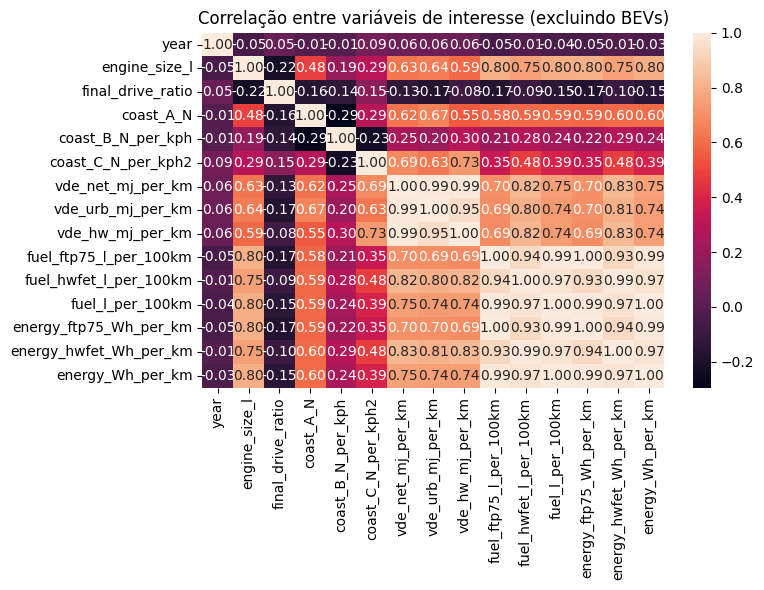

In [56]:
corr_cols = []
df_used = df_filtred[df_filtred["electrification"]!= "BEV"]


# Selecionando colunas para a matriz de correlação
for v in [
        "year",
        "engine_size_l",
        "final_drive_ratio",
        "coast_A_N",
        "coast_B_N_per_kph",
        "coast_C_N_per_kph2",
        "vde_net_mj_per_km",
        "vde_urb_mj_per_km",
        "vde_hw_mj_per_km",
        "fuel_ftp75_l_per_100km",
        "fuel_hwfet_l_per_100km",
        "fuel_l_per_100km",
        "energy_ftp75_Wh_per_km",
        "energy_hwfet_Wh_per_km",
        "energy_Wh_per_km",
]:
    if v in df_used.columns:
        corr_cols.append(v)

# Calculando a matriz de correlação
corr_matrix = df_used[corr_cols].corr()


# Plotando a matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlação entre variáveis de interesse (excluindo BEVs)")
plt.tight_layout()
plt.show()

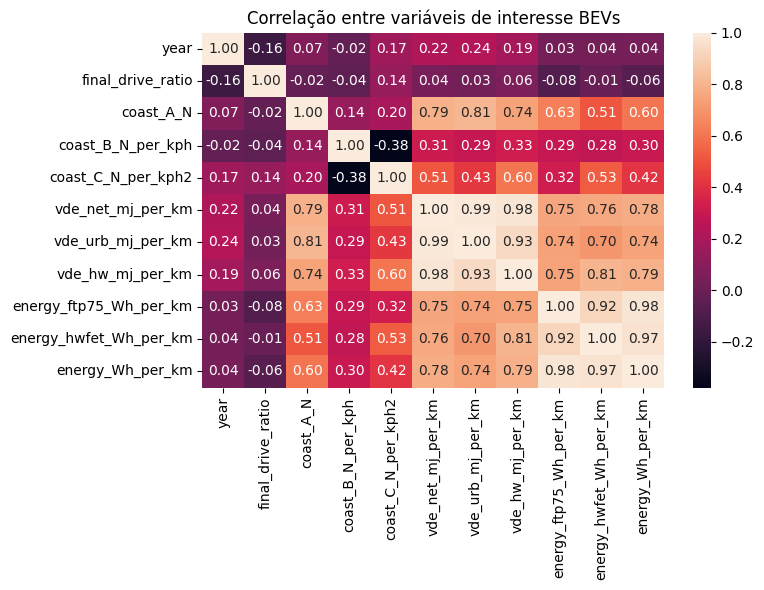

In [57]:
corr_cols = []
df_used = df_filtred[df_filtred["electrification"]== "BEV"]


# Selecionando colunas para a matriz de correlação
for v in [
        "year",
        "final_drive_ratio",
        "coast_A_N",
        "coast_B_N_per_kph",
        "coast_C_N_per_kph2",
        "vde_net_mj_per_km",
        "vde_urb_mj_per_km",
        "vde_hw_mj_per_km",
        "energy_ftp75_Wh_per_km",
        "energy_hwfet_Wh_per_km",
        "energy_Wh_per_km",
]:
    if v in df_used.columns:
        corr_cols.append(v)

# Calculando a matriz de correlação
corr_matrix = df_used[corr_cols].corr()


# Plotando a matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlação entre variáveis de interesse BEVs")
plt.tight_layout()
plt.show()

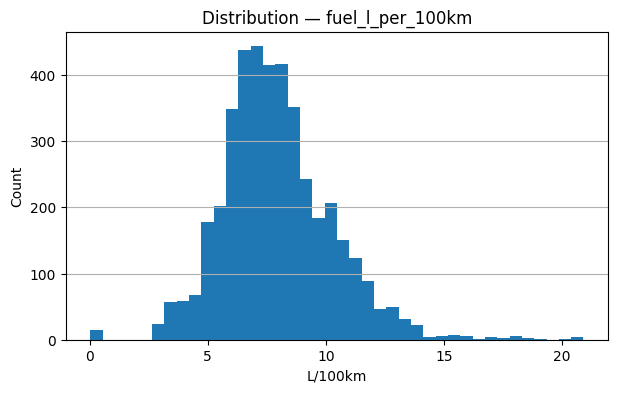

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(df_filtred["fuel_l_per_100km"].dropna(), bins=40)
plt.title("Distribution — fuel_l_per_100km")
plt.xlabel("L/100km")
plt.ylabel("Count")
plt.grid(True, axis="y")
plt.show()


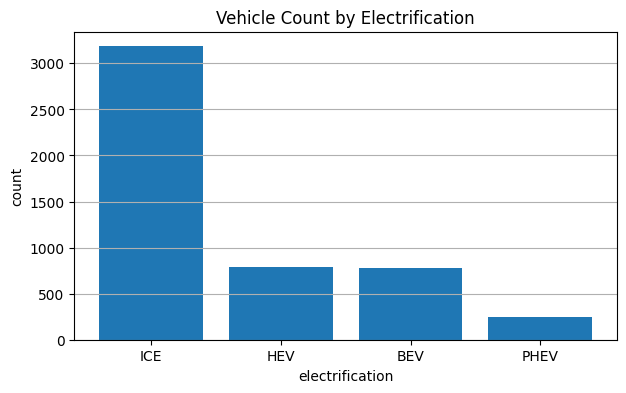

In [59]:

counts = df_filtred["electrification"].value_counts()
plt.figure(figsize=(7,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Vehicle Count by Electrification")
plt.xlabel("electrification")
plt.ylabel("count")
plt.grid(True, axis="y")
plt.show()


## **Not BEV Vehicles Analysis**

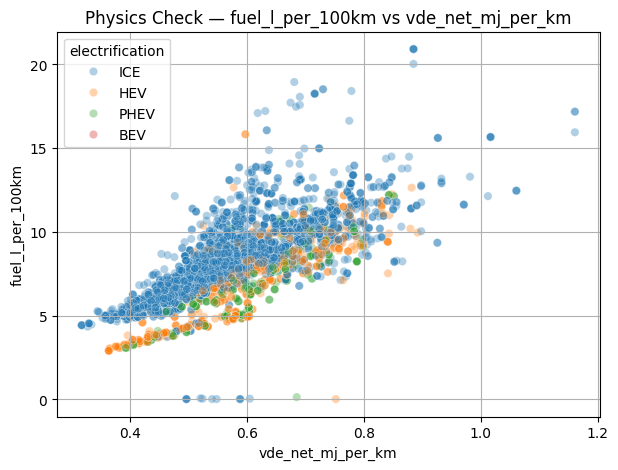

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_filtred,
    x="vde_net_mj_per_km",
    y="fuel_l_per_100km",
    hue="electrification",
    alpha=0.35
)
plt.title("Physics Check — fuel_l_per_100km vs vde_net_mj_per_km")
plt.xlabel("vde_net_mj_per_km")
plt.ylabel("fuel_l_per_100km")
plt.grid(True)
plt.show()


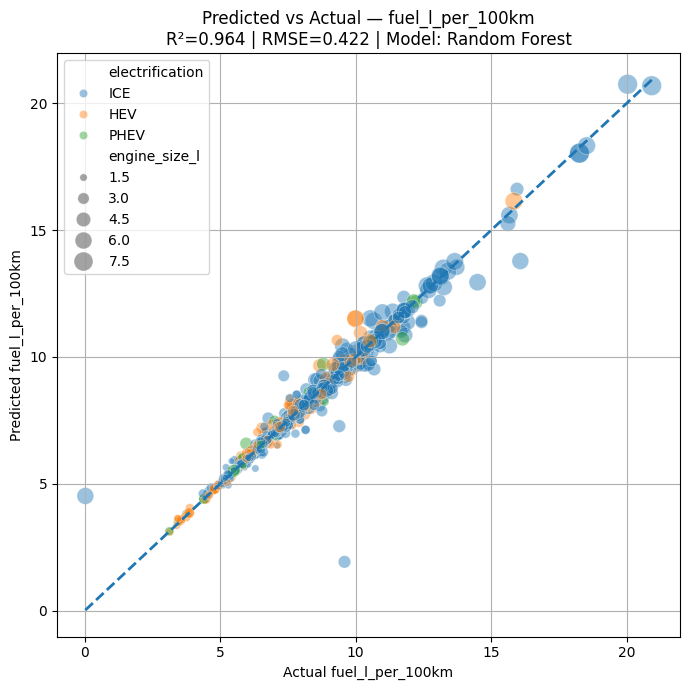

In [61]:

from sklearn.metrics import r2_score, mean_squared_error

y_test = y_fc_nbev_test["fuel_l_per_100km"]

# Definir modelo enumerados 1. "Random Forest" | 2. "Linear Regression" | 3. "Neural Network" 
model_name = "Random Forest"
y_pred = y_nbev_pred_1[:, 2]


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plot_df = X_fc_nbev_test.copy()
plot_df["y_true"] = y_test.values
plot_df["y_pred"] = y_pred

plt.figure(figsize=(7,7))
sns.scatterplot(
    data=plot_df,
    x="y_true",
    y="y_pred",
    hue="electrification",
    size="engine_size_l",
    sizes=(20, 200),
    alpha=0.45
    
)

mn = min(plot_df["y_true"].min(), plot_df["y_pred"].min())
mx = max(plot_df["y_true"].max(), plot_df["y_pred"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2)

plt.title(f"Predicted vs Actual — fuel_l_per_100km\nR²={r2:.3f} | RMSE={rmse:.3f} | Model: {model_name}")
plt.xlabel("Actual fuel_l_per_100km")
plt.ylabel("Predicted fuel_l_per_100km")
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
import mplcursors
# --- cursor interativo ---
cursor = mplcursors.cursor(ax.collections, hover=True)

@cursor.connect("add")
def on_add(sel):
    idx = sel.index
    row = plot_df.iloc[idx]
    sel.annotation.set_text(
        f"Actual: {row['y_true']:.2f}\n"
        f"Pred: {row['y_pred']:.2f}\n"
        f"Error: {row['error']:.2f}\n"
        f"Engine: {row['engine_size_l']:.2f} L\n"
        f"PWT: {row['electrification']}"
    )

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'mplcursors'

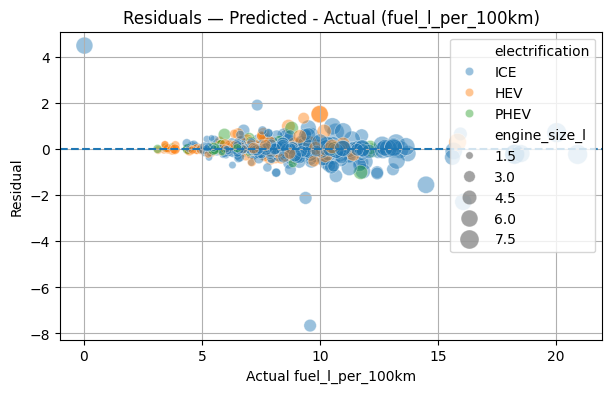

In [63]:
res = y_pred - y_test

plt.figure(figsize=(7,4))

sns.scatterplot(  
                data=plot_df,
                x=y_test,
                y=res,
                hue="electrification",
                size="engine_size_l",
                sizes=(20, 200),
                alpha=0.45
    
                )
plt.axhline(0, linestyle="--")
plt.title("Residuals — Predicted - Actual (fuel_l_per_100km)")
plt.xlabel("Actual fuel_l_per_100km")
plt.ylabel("Residual")
plt.grid(True)
plt.show()


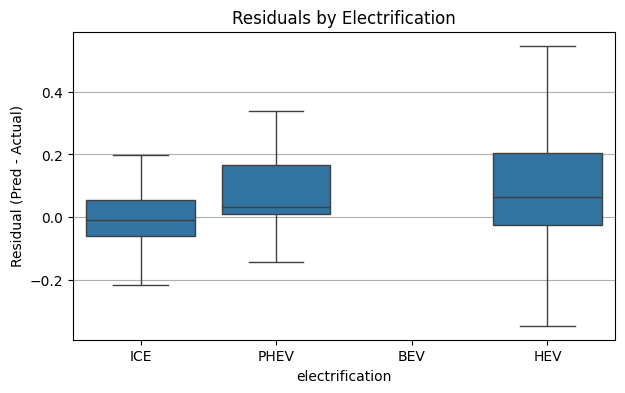

In [64]:
err_df = X_test.copy()
err_df["residual"] = res

plt.figure(figsize=(7,4))
sns.boxplot(data=err_df, x="electrification", y="residual", showfliers=False)
plt.title("Residuals by Electrification")
plt.xlabel("electrification")
plt.ylabel("Residual (Pred - Actual)")
plt.grid(True, axis="y")
plt.show()


In [66]:
df_filtred["pt_efficiency_fuel_over_vde"] = (
    df_filtred["fuel_l_per_100km"] / df_filtred["vde_net_mj_per_km"]
)


C:\Users\CaioHenriqueFerreira\AppData\Local\Temp\ipykernel_9536\925000597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtred["pt_efficiency_fuel_over_vde"] = (


-- --

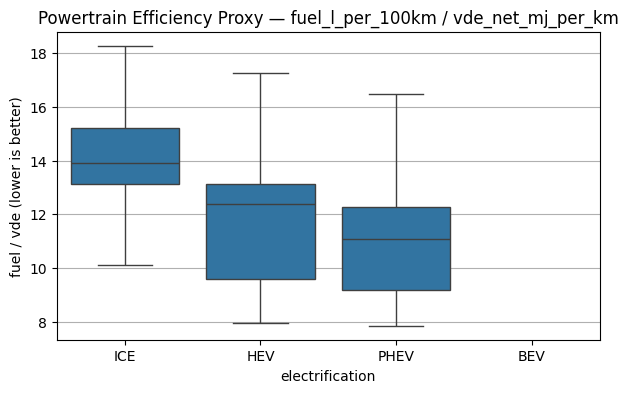

In [67]:
plt.figure(figsize=(7,4))
sns.boxplot(
    data=df_filtred,
    x="electrification",
    y="pt_efficiency_fuel_over_vde",
    showfliers=False
)
plt.title("Powertrain Efficiency Proxy — fuel_l_per_100km / vde_net_mj_per_km")
plt.xlabel("electrification")
plt.ylabel("fuel / vde (lower is better)")
plt.grid(True, axis="y")
plt.show()


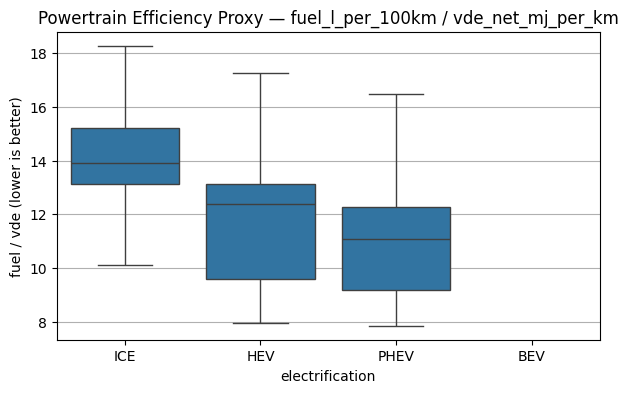

In [68]:
plt.figure(figsize=(7,4))
sns.boxplot(
    data=df_filtred,
    x="electrification",
    y="pt_efficiency_fuel_over_vde",
    showfliers=False
)
plt.title("Powertrain Efficiency Proxy — fuel_l_per_100km / vde_net_mj_per_km")
plt.xlabel("electrification")
plt.ylabel("fuel / vde (lower is better)")
plt.grid(True, axis="y")
plt.show()


## **BEV Analysis**

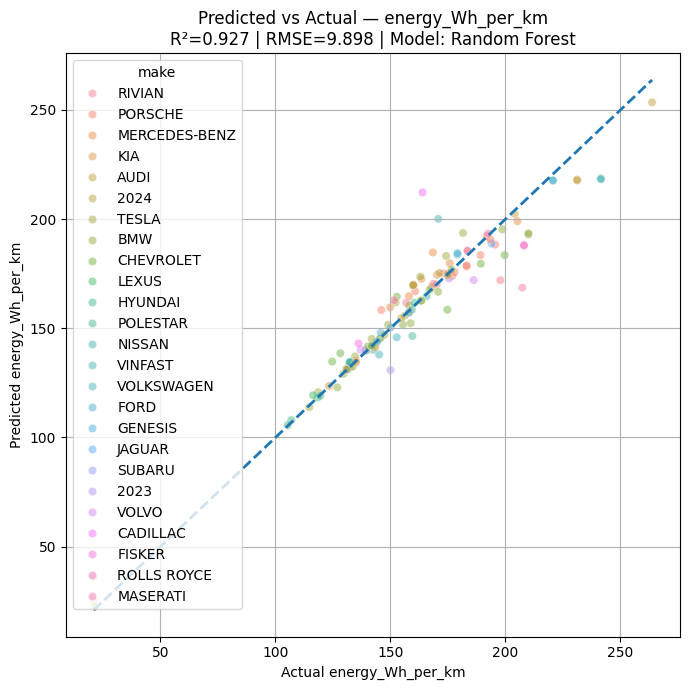

In [72]:

from sklearn.metrics import r2_score, mean_squared_error

y_test = y_fc_bev_test["energy_Wh_per_km"]

# Definir modelo enumerados 1. "Random Forest" | 2. "Linear Regression" | 3. "Neural Network" 
model_name = "Random Forest"
y_pred = y_bev_pred_1[:, 2]


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plot_df = X_fc_bev_test.copy()
plot_df["y_true"] = y_test.values
plot_df["y_pred"] = y_pred

plt.figure(figsize=(7,7))
sns.scatterplot(
    data=plot_df,
    x="y_true",
    y="y_pred",
    hue="make",
    sizes=(20, 200),
    alpha=0.45
    
)

mn = min(plot_df["y_true"].min(), plot_df["y_pred"].min())
mx = max(plot_df["y_true"].max(), plot_df["y_pred"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2)

plt.title(f"Predicted vs Actual — energy_Wh_per_km\nR²={r2:.3f} | RMSE={rmse:.3f} | Model: {model_name}")
plt.xlabel("Actual energy_Wh_per_km")
plt.ylabel("Predicted energy_Wh_per_km")
plt.grid(True)
plt.tight_layout()
plt.show()

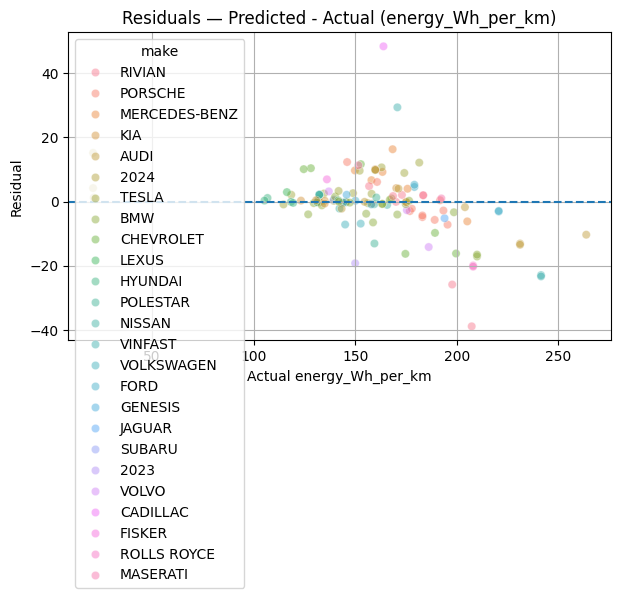

In [73]:
res = y_pred - y_test

plt.figure(figsize=(7,4))

sns.scatterplot(  
                data=plot_df,
                x=y_test,
                y=res,
                hue="make",
                sizes=(20, 200),
                alpha=0.45
    
                )
plt.axhline(0, linestyle="--")
plt.title("Residuals — Predicted - Actual (energy_Wh_per_km)")
plt.xlabel("Actual energy_Wh_per_km")
plt.ylabel("Residual")
plt.grid(True)
plt.show()


# ⚡ EcoDrive Analyzer

## 👨‍🔬 CS50 Explaning Video

**Eco Drive Analyzer**
- YouTube: [Watch on YouTube](https://youtu.be/yQ4lP8M8Cw0)


---

**Vehicle Demanded Energy (VDE) Benchmarking Tool**

A scientific and transparent platform for vehicle energy analysis, regulatory comparison, and efficiency visualization.
Developed as part of the **CS50 Final Project** by *Caio H. F. Rocha* (2025).

---

## 🚗 Overview

**EcoDrive Analyzer** quantifies and visualizes the **Vehicle Demanded Energy (VDE)** —
the minimum mechanical energy required for a vehicle to follow a driving cycle under standardized road-load conditions.

It provides a **transparent, physics-based** framework aligned with **EPA, WLTP, and PROCONVE** methodologies (WLTP Lack of Data, PROCONVE (BR) To be implemented).

---
## 🌱 Motivation

**EcoDrive Analyzer** was created as part of my CS50 journey — a way to connect **engineering precision with human clarity**.
It reflects my aim to build tools that make efficiency measurable, transparent, and grounded in physics.

Through this project, I learned to **value clarity over speed**, to turn theory into something reproducible, and to find meaning in making science visible.

> “It’s not about doing more. It’s about doing with clarity and impact.”

---

## 🧠 Core Concept

\[
VDE = \int (F_{road}(v) + m_{test} a(t)) \, v(t) \, dt
\]

- \(F_{road}(v) = A + Bv + Cv^2\)
- \(m_{test}\): equivalent test mass (ETW / WLTP)
- \(v(t), a(t)\): speed and acceleration profiles from cycle traces

The **VDE** is then normalized by the total cycle distance → expressed in **MJ/km**.

---

## ⚙️ Road-Load Components

| Symbol | Description | Main Source | Unit |
|:--:|:--|:--|:--:|
| **A** | Rolling + Parasitic Resistance | Tire deformation, bearings, drivetrain drag | N |
| **Bv** | Speed-proportional Losses | Transmission, bearings | N/kph |
| **Cv²** | Aerodynamic Drag | Air resistance (Cd × Af) | N/kph² |

---

## 🔋 Tractive and Demanded Energy

\[
P_{tractive}(t) = (F_{road}(v) + m_{test} a(t)) \cdot v(t)
\]

\[
VDE_{NET} = \frac{1}{d_{cycle}} \int P_{tractive}(t)\,dt
\]

- **VDE_NET** → ideal tractive energy (transmission in neutral).
- **VDE_TOTAL** → includes drivetrain losses for real-world correlation.

---

## 🧩 Features

- **📥 VDE Setup** – load driving cycles and parameters (A/B/C, mass).
- **⚙️ PWT Fuel Energy** – compute Vehicle Demanded Energy (VDE_NET).
- ***🧮 Regression Card*** – correlate VDE with fuel consumption based on EPA Tested Data (WLTP missing data for now).
- **💾 Local Database (SQLite)** – stores every snapshot and calculation.
- **📊 Operating Points / Report (TO DO)** – visualize PWT operating points based on Transmission & Engine or Electric Motor.
- **🧠 Scenario Analysis** – test efficiency improvements (mass, aero, tires). Comparison Report to be improved bur it can be done by VDE Setup.

---

## 🧪 Scientific Methodology

The analysis pipeline follows a transparent and reproducible process:

1. **Input Data:** coastdown coefficients, mass, and cycle trace.
2. **Compute VDE_NET:** road-load + inertia + integration over time.
3. **Add Transmission Losses (optional):** derive VDE_TOTAL.
4. **Regression Analysis:** correlate VDE with measured fuel consumption.
5. **Visualization:** energy breakdown, deltas, and correlations.

---

## 🧬 Data Sources

- 🇺🇸 **EPA 40 CFR 1066** – U.S. vehicle test procedure.
- 🇪🇺 **UNECE GTR 15 / WLTP** – Worldwide harmonized light vehicles test.
- 🇧🇷 **INMETRO / PBEV** – Brazilian fuel economy dataset.
- **SAE J1263 / J2263** – Road-load and coastdown measurement standards.
- **SAE 2020-01-1064 / ICCT 2014** – Transmission losses and correlation studies.

---

## 🖥️ Tech Stack

| Layer | Technology |
|:--|:--|
| Frontend | Streamlit |
| Backend | Python 3.11 |
| Database | SQLite3 |
| Visualization | Plotly / Matplotlib |
| Data Handling | Pandas / NumPy |
| Reports | Markdown / PDF (via ReportLab) |

---

## 📊 Machine Learning Analysis (scikit-learn)

The project includes a small ML module built with scikit-learn to validate the physical models and explore predictive relationships in the EPA dataset.

A first experiment used only categorical attributes (make, category, powertrain, transmission) to predict coastdown coefficients A/B/C, reaching R² ≈ 0.70, showing strong structural patterns across vehicle classes.

A second model combined coastdown coefficients and basic vehicle parameters to predict certified fuel consumption, achieving R² ≈ 0.96 with a Random Forest.
This aligns with vehicle physics: road load → RLHP → FE.

These models complement the physics-based VDE workflow and help validate data consistency, estimate missing values, and accelerate early-stage benchmarking.

---

## 🧰 Folder Structure

```
EcoDrive-Analyzer/
│
├── app.py                      # Main Streamlit entry point
├── data/
│   └── db/eco_drive.db         # Local database (auto-generated)
│   └── cycles/                 # Cycles USed
│   └── vehicles/               # Vehicles Data
│   └── standards/              # Standards
│   └── images/              # Standards
|
│
├── pages/
│   ├── home_page.py            # Home with methodology and theory
│   ├── vde_setup.py            # Load cycle and setup parameters
│   ├── pwt_fuel_energy.py      # Compute VDE & energy KPIs
│   └── operating_points.py     # Regression & comparison dashboards
│
├── src/
│   └── vde_core/               # Core calculation modules
│       ├── db.py
│       ├── services.py
│       ├── regression.py
│       └── utils.py
│   └── vde_app/               # app modules
│       ├── components.py
│       ├── derivatives.py
│       ├── plots.py
│       └── state.py
|
├── EPA_xlsx_to_db.ipynb       # Pre Processing data from EPA & Manage initial DB
|
└── README.md
```

---

## 🧮 Mathematical Layers

| Layer | Description | Output |
|:--|:--|:--:|
| **VDE_NET** | Vehicle Demanded Energy (neutral) | MJ/km |
| **VDE_TOTAL** | Includes drivetrain losses | MJ/km |
| **ΔTech Scenarios** | Compare aero, mass, tires, hybridization | % Δ MJ/km |

---

## 🧭 Roadmap (MVPs)

| Stage | Goal | Status |
|:--|:--|:--:|
| **MVP0** | Core physical computation (EPA/WLTP cycles) | ✅ Complete |
| **MVP1** | Database + Streamlit UI | ✅ Finalizing |
| **MVP2** | ML Regression & Scenario Analysis + Insert Components Maps & Gather more vehicle info  | ⚙️ In Progress |
| **MVP3** | Transmission Losses + BEV/PHEV extensions | 🔜 Planned |
| **MVP4** | ML Application using Scikit Learning to determine specific components efficiency | 🔜 Planned |

---

## 📈 Example Output

```
Cycle: FTP-75
-------------------------------------
VDE_urban_NET   = 1.82 MJ/km
VDE_highway_NET = 1.15 MJ/km
VDE_comb_NET    = 1.56 MJ/km
```

---

## 🧪 Installation

```bash
# Clone repository (root repo contains the EcoDrive-Analyst folder)
git clone https://github.com/caiohfr/projects.git
cd projects/EcoDrive-Analyst

# Create virtual environment
python -m venv .venv
source .venv/Scripts/activate   # Windows: .venv\Scripts\activate

# Install dependencies
pip install -r requirements.txt

# Run Streamlit app
streamlit run app.py
```

---

## 🧩 Usage

1. Launch the Streamlit interface:
   ```bash
   streamlit run app.py
   ```
2. Open your browser (`http://localhost:8501`).
3. Workflow:
   - **📥 VDE Setup:** Create new vehicle profile
   - **⚙️ PWT Fuel Energy:** PWT Data, correlate Fuel Economy w/ vehicle Data
   - **📊 Comparison Report: (TO DO)** Need more Data visualization & Analysis tool to be implemented
   - **📊 Operating Points: (TO DO)** analyze specific points during cycle, need PWT specific maps. Future Application

---

## 🧾 Transparency & Reproducibility

- 100% based on **public, normative data and formulas**.
- No proprietary models or closed datasets.
- All results traceable to physical inputs and database entries.

---

## 👨‍🔬 Author

**Caio H. F. Rocha**
*Automotive Engineer MSc – Stellantis / CS50 Student*
- LinkedIn: [LinkedIn - Caio H. F. Rocha](https://www.linkedin.com/in/caio-henrique-ferreira-rocha-728011140/)
- GitHub: [GitHub - caiohfr](https://github.com/caiohfr)

---

## 🧠 License

This project is distributed under the **MIT License**.
You are free to use, modify, and distribute with proper credit.

---

## 🏁 Acknowledgments

- **Harvard CS50** – for the foundation in computational thinking.
- **SAE / ICCT / UNECE** – for the open regulatory frameworks.
- **Streamlit Team** – for simplifying scientific dashboards.

---

### 📚 Citation

If you use this project in research or academic work, please cite as:

> Rocha, C.H.F. (2025). *EcoDrive Analyzer – A Transparent Tool for Vehicle Demanded Energy Benchmarking*. CS50 Final Project.

